# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [78]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt
data = {
    "name": [
        "Alice","Bob","Charlie","David","Ethan","Finn",
        "Grace","Hannah","Ian","Jack","Kara","Liam",
        "Mona","Nate","Olivia"
    ],
    "followers": [
        50,120,30,500,450,600,
        80,300,150,220,400,90,
        275,130,520
    ],
    "friends": [
        20,80,15,300,250,400,
        25,200,100,180,350,60,
        240,110,480
    ],
    "label": [
        0,0,0,1,1,1,
        0,1,0,1,1,0,
        1,0,1
    ]
}

df = pd.DataFrame(data)



## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [79]:
print(df.head())

      name  followers  friends  label
0    Alice         50       20      0
1      Bob        120       80      0
2  Charlie         30       15      0
3    David        500      300      1
4    Ethan        450      250      1


Display the summary of all the features of the dataset using `.info()`

In [80]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       15 non-null     object
 1   followers  15 non-null     int64 
 2   friends    15 non-null     int64 
 3   label      15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 612.0+ bytes
None


Display the total number of samples from each label using `.value_counts()`

In [81]:
print(df["label"].value_counts())

label
1    8
0    7
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

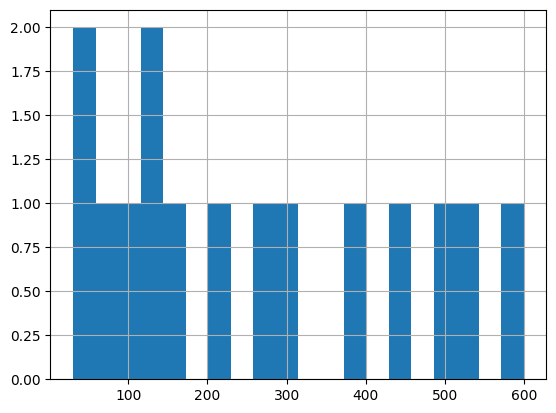

In [82]:
df["followers"].hist(bins=20)
plt.show()

Remove the name column using `drop()` method

In [83]:
df = df.drop("name", axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [84]:
X = df.drop("label", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [85]:
y = df["label"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Display the dimensions of each variables using `.shape()`

In [87]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (10, 2)
X_test: (5, 2)
y_train: (10,)
y_test: (5,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [89]:
knn = KNeighborsClassifier(n_neighbors=3)

Train the model using the `.fit()`

In [90]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

Test the model using the `.predict()`

In [91]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

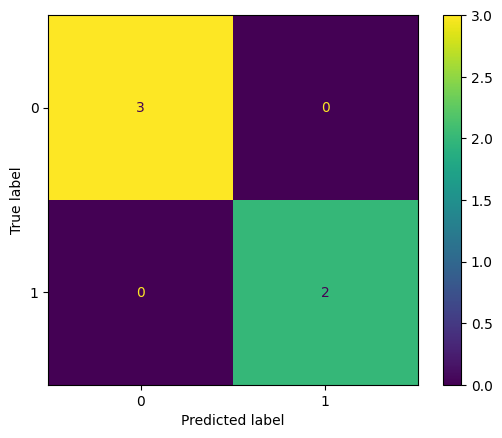

In [92]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Display the accuracy

In [93]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Display the precision

In [94]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 1.0


Display the recall

In [95]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 1.0


Display the f1-score

In [96]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 1.0


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [97]:
my_features = [[200, 150]]
prediction = knn.predict(my_features)
print("Predicted personality:", "Extrovert" if prediction[0] == 1 else "Introvert")

Predicted personality: Introvert
